In [2]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

In [33]:
zero = basis(3,0)
one = basis(3,1)
two = basis(3,2)

e_ops =[ket2dm(zero),
            ket2dm(one),
            ket2dm(two)]
H = [identity(3)]
tlist =  np.linspace(0,1,500)

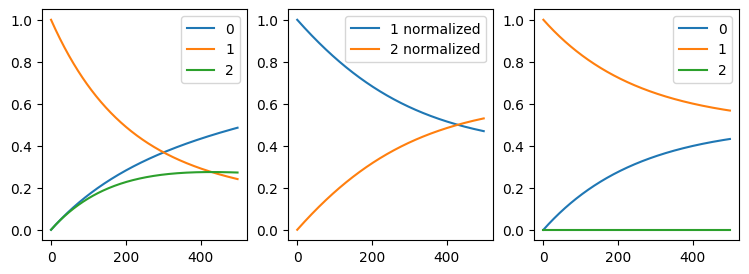

In [38]:
upside_down_c_ops = [lindblad_dissipator(one * two.dag()) +
                         lindblad_dissipator(two * one.dag()) + 
                         lindblad_dissipator(zero * one.dag())]
conventional_fluxonium_c_ops = [lindblad_dissipator(one * zero.dag()) +
                         lindblad_dissipator(zero * one.dag())]

fig,axes = plt.subplots(1,3,figsize=(9,3))

result = mesolve(H = H, 
                rho0 = one, 
                tlist = tlist, 
                c_ops = upside_down_c_ops,
                e_ops = e_ops,
                )
for ql, arr in enumerate(result.expect):
    axes[0].plot(arr,label= f"{ql}")

sum = result.expect[1] + result.expect[2]
axes[1].plot(result.expect[1]/sum,label= f"{1} normalized")
axes[1].plot(result.expect[2]/sum,label= f"{2} normalized")

result = mesolve(H = H, 
                rho0 = one, 
                tlist = tlist, 
                c_ops = conventional_fluxonium_c_ops,
                e_ops = e_ops,
                )
for ql, arr in enumerate(result.expect):
    axes[2].plot(arr,label= f"{ql}")

axes[0].legend()
axes[1].legend()
axes[2].legend()